In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

In [63]:
np.random.uniform(3,70, size=10)

array([25.16063917, 48.89383458, 22.25174699, 44.49905925, 19.95153601,
       29.4198922 , 25.65054944, 51.91156546, 52.50107665, 13.61032395])

In [60]:
info = pd.read_csv('../data/tornados_all.csv')

In [61]:
info

,YEAR,MONTH,RADAR_DIST,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,TOR_F_SCALE,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV
0,1990,6,91.212078,44.3700,-92.6300,44.4200,-92.5800,F1,0,0,0,0,25000.0,0.0,True
1,1990,6,127.396500,40.2500,-100.7500,40.2700,-100.5300,F4,0,0,0,0,2500000.0,0.0,True
2,1990,6,85.495236,40.0500,-97.5000,40.0800,-97.4200,F1,0,0,0,0,25000.0,0.0,True
3,1990,6,89.959493,40.0300,-99.4300,40.0300,-99.1300,F1,0,0,0,0,25000.0,0.0,True
4,1990,6,121.606645,41.3700,-98.8500,41.4200,-98.7800,F1,0,0,0,0,25000.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26064,2025,9,164.471312,48.2490,-100.8390,48.2510,-100.8400,EFU,0,0,0,0,0.0,0.0,True
26065,2025,6,55.949806,37.2391,-98.0398,37.2395,-98.0388,EF0,0,0,0,0,0.0,0.0,True
26066,2025,9,60.483547,47.1400,-100.1750,47.1790,-100.1590,EFU,0,0,0,0,0.0,0.0,True
26067,2025,6,116.128617,36.1732,-101.1485,36.0550,-101.0970,EF2,0,0,0,0,95000.0,0.0,True


Seems like even at 0-100 km away from the nearest radar, there is about 1-5 deaths or injuries per tornado event.

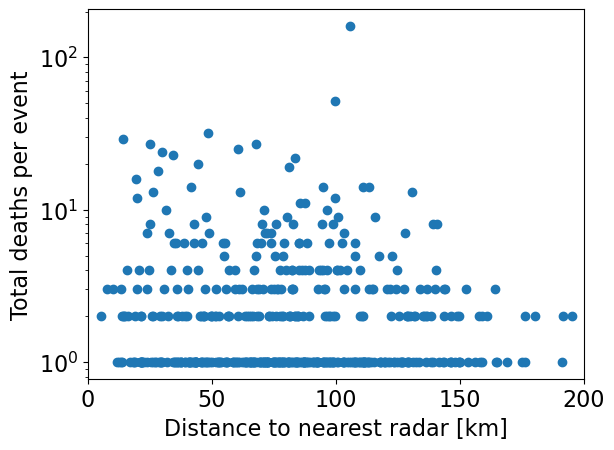

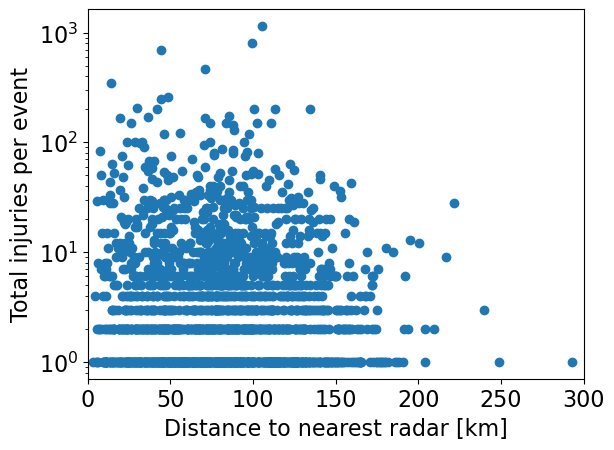

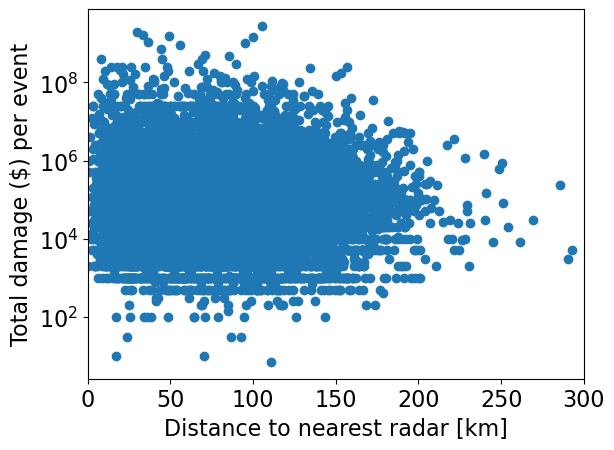

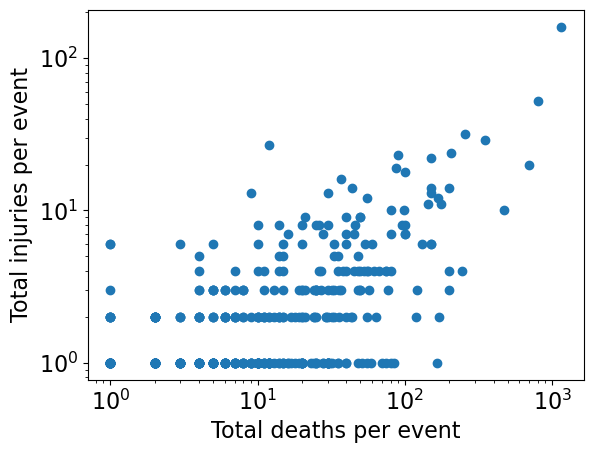

In [62]:
plt.figure()

total_deaths = np.array(info['DEATHS_DIRECT']) + np.array(info['DEATHS_INDIRECT'])

filt = total_deaths > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_deaths[filt])
plt.xlim([0,200])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total deaths per event')
#plt.ylim([0,20])


plt.figure()
total_injuries = np.array(info['INJURIES_DIRECT']) + np.array(info['INJURIES_INDIRECT'])

filt = total_injuries > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_injuries[filt])
plt.xlim([0,300])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total injuries per event')
#plt.ylim([0,20])


plt.figure()
total_damage = np.array(info['DAMAGE_PROPERTY']) + np.array(info['DAMAGE_CROPS'])

filt = total_damage > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_damage[filt])
plt.xlim([0,300])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total damage ($) per event')



plt.figure()
total_deaths = np.array(info['DEATHS_DIRECT']) + np.array(info['DEATHS_INDIRECT'])
total_injuries = np.array(info['INJURIES_DIRECT']) + np.array(info['INJURIES_INDIRECT'])

filt = (total_deaths > 0) * (total_injuries > 0)
plt.scatter(total_injuries[filt], total_deaths[filt])
plt.xlabel('Total deaths per event')
plt.ylabel('Total injuries per event')
plt.xscale('log')
plt.yscale('log')
#plt.ylim([0,20])

(array([1956., 2396., 4638., 5562., 3502., 1973., 1560., 1008., 1188.,
        2286.]),
 array([ 1. ,  2.1,  3.2,  4.3,  5.4,  6.5,  7.6,  8.7,  9.8, 10.9, 12. ]),
 <BarContainer object of 10 artists>)

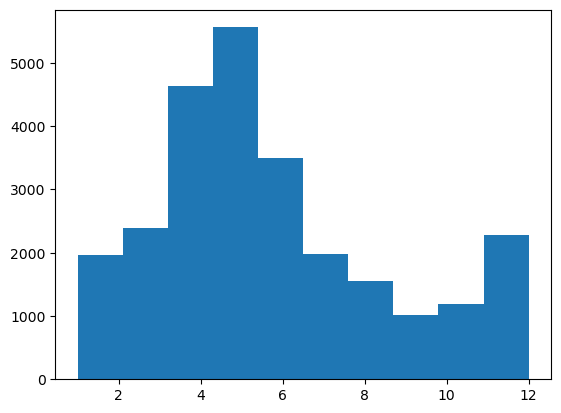

In [44]:
plt.figure()
plt.hist(info['MONTH'])